<a href="https://colab.research.google.com/github/prof-atritiack/CP1-SERS-Analise/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Criando DataFrame 'dados'
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
# Desenvolva aqui o DESAFIO 1
# Quantidade de linhas e colunas
print(f'Total de registros: {dados.shape[0]}')
print(f'Total de colunas: {dados.shape[1]}')

Total de registros: 336
Total de colunas: 11


In [ ]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


In [ ]:
df_carga.head()

,area,data_hora,carga
0,SP,2025-08-01 03:30:00+00:00,15913.618
1,SP,2025-08-01 04:00:00+00:00,15251.414
2,SP,2025-08-01 04:30:00+00:00,14606.733
3,SP,2025-08-01 05:00:00+00:00,14182.290
4,SP,2025-08-01 05:30:00+00:00,13838.488


In [ ]:
df_carga.shape

(336, 3)

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3

In [ ]:
min_carga = df_carga['carga'].min()
max_carga = df_carga['carga'].max()
media_carga = df_carga['carga'].mean()
mediana_carga = df_carga['carga'].median()
amplitude_carga = max_carga - min_carga
quantidade_medicoes = df_carga.shape[0]

print(f"### Indicadores da Carga Elétrica\n")
print(f"Carga Mínima: {min_carga:.3f}")
print(f"Carga Máxima: {max_carga:.3f}")
print(f"Carga Média: {media_carga:.3f}")
print(f"Mediana da Carga: {mediana_carga:.3f}")
print(f"Amplitude da Carga (Máx - Mín): {amplitude_carga:.3f}")
print(f"Quantidade Total de Medições: {quantidade_medicoes}\n")

### Indicadores da Carga Elétrica

Carga Mínima: 12139.253
Carga Máxima: 23185.312
Carga Média: 17870.829
Mediana da Carga: 18199.128
Amplitude da Carga (Máx - Mín): 11046.059
Quantidade Total de Medições: 336



### Análise do Comportamento da Carga Máxima

Com base nos indicadores calculados:

- **Carga Mínima:** 12139.253
- **Carga Máxima:** 23185.312
- **Carga Média:** 17870.829
- **Mediana da Carga:** 18199.128
- **Amplitude da Carga (Máx - Mín):** 11046.059

O valor máximo da carga (23185.312) está significativamente acima da carga média (17870.829) e da mediana (18199.128). Isso sugere que, embora haja um comportamento médio e uma tendência central, existem picos de demanda que se destacam consideravelmente, levando a uma amplitude de 11046.059. Portanto, sim, o valor máximo está distante do comportamento médio observado, indicando que a rede elétrica deve ser capaz de lidar com esses picos de demanda que excedem em muito a carga típica.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# DESAFIO 4 — Períodos de alta demanda

# 1. Calcule o limiar (90% da carga máxima)
limiar_alta_demanda = df_carga['carga'].max() * 0.90

# 2. Crie um novo DataFrame com os registros acima dele.
df_alta_demanda = df_carga[df_carga['carga'] > limiar_alta_demanda].copy()

# 3. Conte os registros.
quantidade_alta_demanda = df_alta_demanda.shape[0]

# 4. Calcule o percentual em relação ao total.
percentual_alta_demanda = (quantidade_alta_demanda / df_carga.shape[0]) * 100

# 5. Identifique o maior valor de carga (já é a carga máxima).
maior_valor_alta_demanda = df_alta_demanda['carga'].max()

# 6. Identifique a data e o horário do pico, quando disponíveis.
pico_data_hora = df_alta_demanda[df_alta_demanda['carga'] == maior_valor_alta_demanda]['data_hora'].iloc[0]

print(f"### Análise de Períodos de Alta Demanda\n")
print(f"Limiar de Alta Demanda (90% da carga máxima): {limiar_alta_demanda:.3f}\n")
print("### Registros de Alta Demanda:")
print(df_alta_demanda.head())
print(f"\nQuantidade de Registros de Alta Demanda: {quantidade_alta_demanda}")
print(f"Percentual de Registros de Alta Demanda: {percentual_alta_demanda:.2f}%\n")
print(f"Maior Valor de Carga em Alta Demanda: {maior_valor_alta_demanda:.3f}")
print(f"Data e Hora do Pico de Demanda: {pico_data_hora}\n")

print("**Resposta:** Os períodos próximos ao pico representam uma **pequena parcela** do período analisado, correspondendo a aproximadamente {percentual_alta_demanda:.2f}% dos registros. Isso indica que os momentos de alta demanda são eventos pontuais e não um comportamento constante ao longo do período.\n")

### Análise de Períodos de Alta Demanda

Limiar de Alta Demanda (90% da carga máxima): 20866.781

### Registros de Alta Demanda:
   area                 data_hora      carga
35   SP 2025-08-01 21:00:00+00:00  21088.959
36   SP 2025-08-01 21:30:00+00:00  22398.360
37   SP 2025-08-01 22:00:00+00:00  23185.312
38   SP 2025-08-01 22:30:00+00:00  22903.314
39   SP 2025-08-01 23:00:00+00:00  22358.701

Quantidade de Registros de Alta Demanda: 50
Percentual de Registros de Alta Demanda: 14.88%

Maior Valor de Carga em Alta Demanda: 23185.312
Data e Hora do Pico de Demanda: 2025-08-01 22:00:00+00:00

**Resposta:** Os períodos próximos ao pico representam uma **pequena parcela** do período analisado, correspondendo a aproximadamente {percentual_alta_demanda:.2f}% dos registros. Isso indica que os momentos de alta demanda são eventos pontuais e não um comportamento constante ao longo do período.



## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# DESAFIO 5 — Segundo critério de análise

# 1. Critério escolhido: Carga acima da média
print("### Análise Segundo Critério: Carga Acima da Média\n")
print(f"Critério escolhido: Carga superior à média global ({df_carga['carga'].mean():.3f})\n")

# 2. Crie o novo DataFrame com os registros acima da média.
df_acima_media = df_carga[df_carga['carga'] > df_carga['carga'].mean()].copy()

# 3. Conte a quantidade de registros.
quantidade_acima_media = df_acima_media.shape[0]

# 4. Calcule o percentual em relação ao total.
percentual_acima_media = (quantidade_acima_media / df_carga.shape[0]) * 100

print("### Registros com Carga Acima da Média:")
print(df_acima_media.head())
print(f"\nQuantidade de Registros com Carga Acima da Média: {quantidade_acima_media}")
print(f"Percentual de Registros com Carga Acima da Média: {percentual_acima_media:.2f}%\n")

# 5. Comparação com o conjunto de alta demanda (Desafio 4)
print("### Comparação com o Conjunto de Alta Demanda:\n")
print(f"- **Alta Demanda (carga > 90% da máxima):** {quantidade_alta_demanda} registros ({percentual_alta_demanda:.2f}%)\n")
print(f"- **Carga Acima da Média:** {quantidade_acima_media} registros ({percentual_acima_media:.2f}%)\n")
print("**Conclusão da Comparação:** O critério de 'Carga Acima da Média' engloba uma quantidade muito maior de registros (aproximadamente o dobro) em comparação com o critério de 'Alta Demanda' (carga superior a 90% da máxima). Isso é esperado, pois o limiar da média é naturalmente mais brando do que um percentual muito elevado do pico. O critério de alta demanda foca em eventos extremos, enquanto o de carga acima da média identifica períodos de demanda mais elevadas do que o habitual, mas não necessariamente de pico.\n")

### Análise Segundo Critério: Carga Acima da Média

Critério escolhido: Carga superior à média global (17870.829)

### Registros com Carga Acima da Média:
   area                 data_hora      carga
15   SP 2025-08-01 11:00:00+00:00  18096.023
16   SP 2025-08-01 11:30:00+00:00  18629.395
17   SP 2025-08-01 12:00:00+00:00  18825.176
18   SP 2025-08-01 12:30:00+00:00  19056.504
19   SP 2025-08-01 13:00:00+00:00  19427.822

Quantidade de Registros com Carga Acima da Média: 184
Percentual de Registros com Carga Acima da Média: 54.76%

### Comparação com o Conjunto de Alta Demanda:

- **Alta Demanda (carga > 90% da máxima):** 50 registros (14.88%)

- **Carga Acima da Média:** 184 registros (54.76%)

**Conclusão da Comparação:** O critério de 'Carga Acima da Média' engloba uma quantidade muito maior de registros (aproximadamente o dobro) em comparação com o critério de 'Alta Demanda' (carga superior a 90% da máxima). Isso é esperado, pois o limiar da média é naturalmente mais brando do que 

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

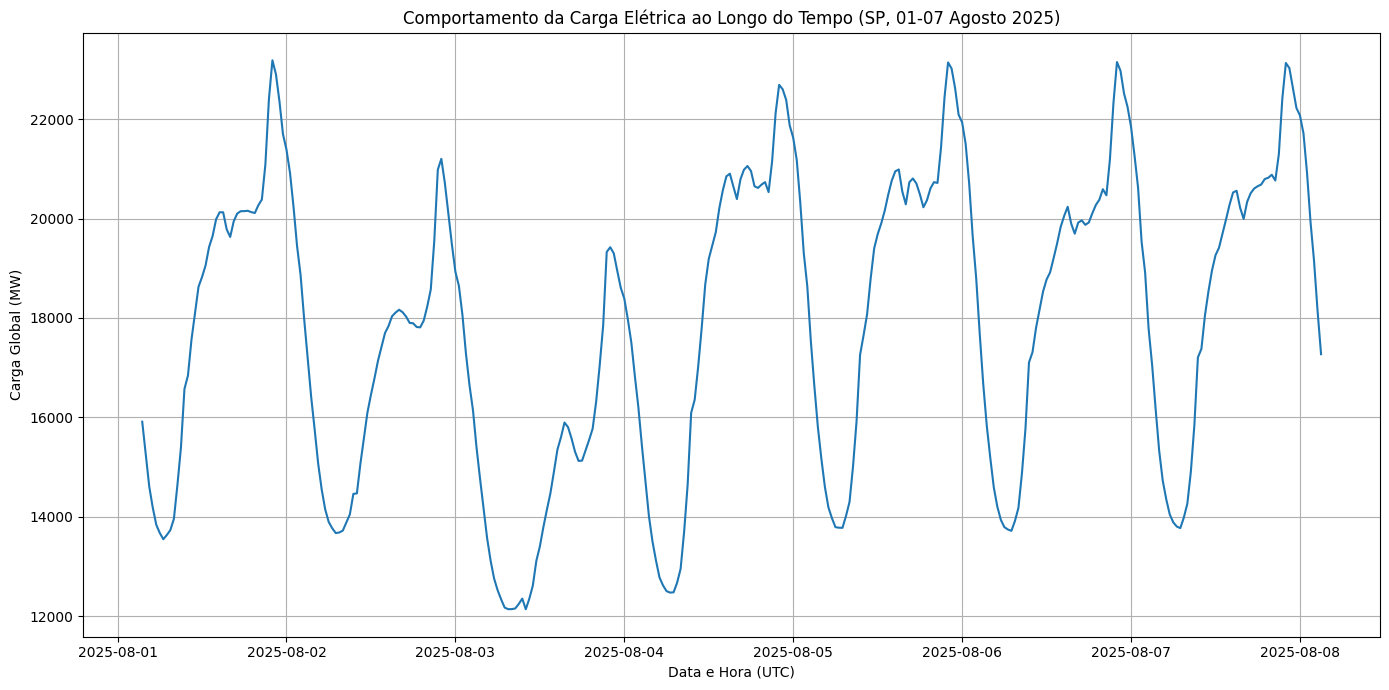

**Interpretação do Gráfico 1:** O gráfico de linha mostra a variação da carga elétrica ao longo dos dias, com padrões diários distintos de picos e vales. Observa-se que a carga tende a ser menor durante a madrugada e maior em determinados períodos do dia, o que é um comportamento típico. Há flutuações e alguns picos mais acentuados que se destacam da tendência geral, confirmando a existência de momentos de alta demanda.



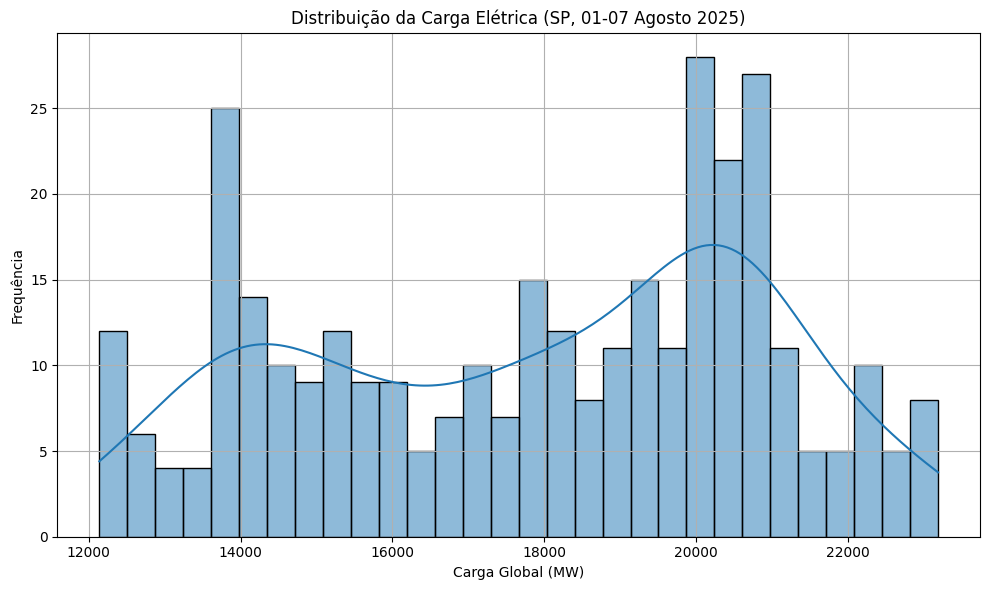

**Interpretação do Gráfico 2:** O histograma mostra a distribuição dos valores de carga. A distribuição não é perfeitamente simétrica, tendendo a ter uma cauda mais longa para valores de carga mais altos, o que indica que os valores de pico, embora menos frequentes, são relevantes e se afastam da média. A maior parte das medições de carga se concentra em uma faixa intermediária, com menos ocorrências de cargas muito baixas ou muito altas.



In [ ]:
# DESAFIO 6 — Visualização

# Gráfico 1: Comportamento da carga ao longo do tempo
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_carga, x='data_hora', y='carga')
plt.title('Comportamento da Carga Elétrica ao Longo do Tempo (SP, 01-07 Agosto 2025)')
plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Carga Global (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("**Interpretação do Gráfico 1:** O gráfico de linha mostra a variação da carga elétrica ao longo dos dias, com padrões diários distintos de picos e vales. Observa-se que a carga tende a ser menor durante a madrugada e maior em determinados períodos do dia, o que é um comportamento típico. Há flutuações e alguns picos mais acentuados que se destacam da tendência geral, confirmando a existência de momentos de alta demanda.\n")

# Gráfico 2: Distribuição da Carga
plt.figure(figsize=(10, 6))
sns.histplot(df_carga['carga'], kde=True, bins=30)
plt.title('Distribuição da Carga Elétrica (SP, 01-07 Agosto 2025)')
plt.xlabel('Carga Global (MW)')
plt.ylabel('Frequência')
plt.grid(True)
plt.tight_layout()
plt.show()

print("**Interpretação do Gráfico 2:** O histograma mostra a distribuição dos valores de carga. A distribuição não é perfeitamente simétrica, tendendo a ter uma cauda mais longa para valores de carga mais altos, o que indica que os valores de pico, embora menos frequentes, são relevantes e se afastam da média. A maior parte das medições de carga se concentra em uma faixa intermediária, com menos ocorrências de cargas muito baixas ou muito altas.\n")

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
resumo_resultados = f'''
Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {quantidade_medicoes}
Carga mínima: {min_carga:.3f}
Carga máxima: {max_carga:.3f}
Carga média: {media_carga:.3f}
Mediana: {mediana_carga:.3f}
Limiar de alta demanda (90% da máxima): {limiar_alta_demanda:.3f}
Registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%
Momento do pico: {pico_data_hora}
Segundo critério (carga acima da média):
  - Quantidade de registros: {quantidade_acima_media}
  - Percentual: {percentual_acima_media:.2f}%
  - Comparação: O critério de 'Carga Acima da Média' engloba uma quantidade muito maior de registros ({quantidade_acima_media}) em comparação com o critério de 'Alta Demanda' ({quantidade_alta_demanda}). Isso indica que o critério da média é mais abrangente, identificando períodos de demanda elevada, mas não necessariamente de pico extremo.
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.253
Carga máxima: 23185.312
Carga média: 17870.829
Mediana: 18199.128
Limiar de alta demanda (90% da máxima): 20866.781
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (carga acima da média):
  - Quantidade de registros: 184
  - Percentual: 54.76%
  - Comparação: O critério de 'Carga Acima da Média' engloba uma quantidade muito maior de registros (184) em comparação com o critério de 'Alta Demanda' (50). Isso indica que o critério da média é mais abrangente, identificando períodos de demanda elevada, mas não necessariamente de pico extremo.



In [ ]:
print('Listando modelos Gemini disponíveis e suas capacidades:')
model_list = list(client.models.list())

for m in model_list:
  if hasattr(m, 'supported_actions') and 'generateContent' in m.supported_actions:
    print(m.name)


Listando modelos Gemini disponíveis e suas capacidades:
Primeiro objeto Model: name='models/gemini-2.5-flash' display_name='Gemini 2.5 Flash' description='Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.' version='001' endpoints=None labels=None tuned_model_info=TunedModelInfo() input_token_limit=1048576 output_token_limit=65536 supported_actions=['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent'] default_checkpoint_id=None checkpoints=None temperature=1.0 max_temperature=2.0 top_p=0.95 top_k=64 thinking=True
Atributos do primeiro objeto Model: ['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__firstlineno__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '_

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO: ANÁLISE DE CARGA ELÉTRICA – REGIÃO SP**

**De:** Analista de Dados do Setor Elétrico  
**Assunto:** Análise Descritiva de Carga e Demanda  
**Período da Amostra:** 01/08/2025 a 07/08/2025  

---

### 1. Caracterização do Conjunto Analisado
O presente relatório analisa o comportamento da carga elétrica na **Região SP** durante o período compreendido entre **01/08/2025 e 07/08/2025**. O conjunto de dados é composto por um total de **336 registros** temporais continuados.

---

### 2. Principais Indicadores
Os dados estatísticos descritivos apurados para o período observam a seguinte distribuição de carga:

*   **Carga Mínima:** 12.139,253
*   **Carga Média:** 17.870,829
*   **Mediana:** 18.199,128
*   **Carga Máxima (Pico):** 23.185,312
*   **Momento do Pico:** 01/08/2025 às 22:00:00 (UTC)

*Nota:* A mediana ligeiramente superior à média indica uma distribuição de carga com sutil deslocamento para valores acima do ponto médio do intervalo.

---

### 3. Análise dos Pe

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**